<a href="https://colab.research.google.com/github/kpate18/ECGR-4105/blob/main/homework%204/Problem_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Load cancer dataset
df = pd.read_csv("Cancer.csv")

df.head()

# Remove columns that are not needed
df = df.drop(columns=["id", "Unnamed: 32"])

# Convert diagnosis:
# M = 1 = Malignant
# B = 0 = Benign
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

df.head()

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Number of features:", X.shape[1])
print("Number of samples:", X.shape[0])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kernels = ["linear", "poly", "rbf", "sigmoid"]

accuracy_list = []
precision_list = []
recall_list = []

for kernel in kernels:

    model = SVC(kernel=kernel)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    accuracy_list.append(accuracy)
    precision_list.append(precision)
    recall_list.append(recall)

    print("\nKernel:", kernel)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)


Number of features: 30
Number of samples: 569
Training samples: 455
Testing samples: 114

Kernel: linear
Accuracy: 0.9649122807017544
Precision: 1.0
Recall: 0.9047619047619048

Kernel: poly
Accuracy: 0.8859649122807017
Precision: 1.0
Recall: 0.6904761904761905

Kernel: rbf
Accuracy: 0.9736842105263158
Precision: 1.0
Recall: 0.9285714285714286

Kernel: sigmoid
Accuracy: 0.9473684210526315
Precision: 0.9736842105263158
Recall: 0.8809523809523809


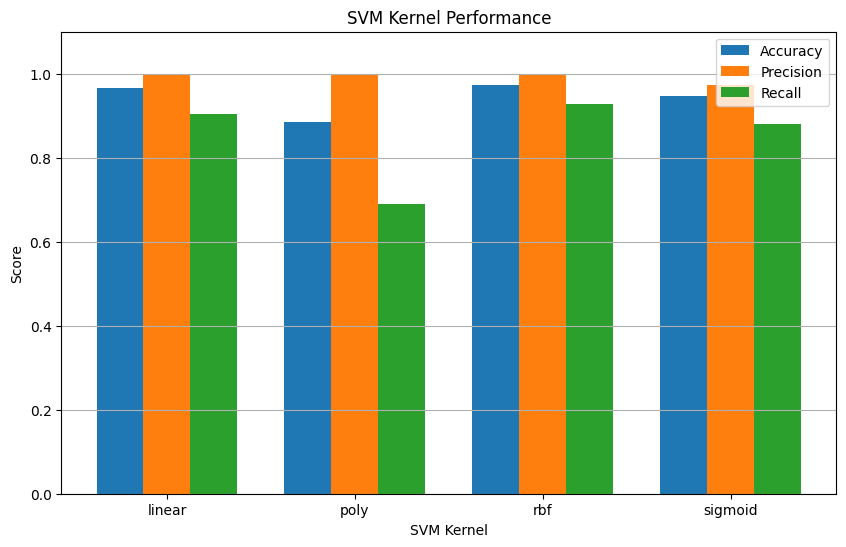

In [8]:
x = np.arange(len(kernels))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - width, accuracy_list, width, label="Accuracy")
plt.bar(x, precision_list, width, label="Precision")
plt.bar(x + width, recall_list, width, label="Recall")

plt.xticks(x, kernels)

plt.xlabel("SVM Kernel")
plt.ylabel("Score")
plt.title("SVM Kernel Performance")

plt.ylim(0, 1.1)

plt.legend()
plt.grid(axis="y")

plt.show()


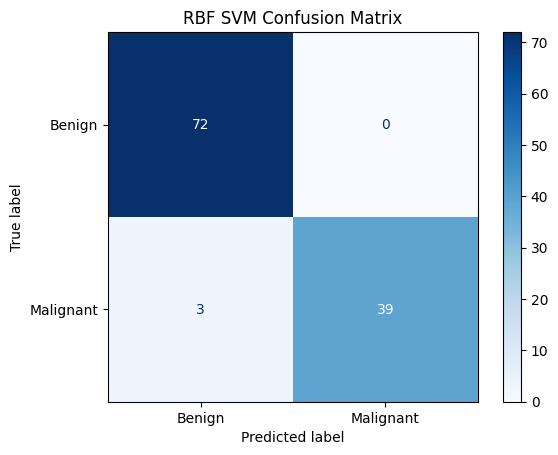

In [9]:
best_model = SVC(kernel="rbf")

best_model.fit(X_train_scaled, y_train)

y_pred_rbf = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_rbf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot(cmap="Blues")

plt.title("RBF SVM Confusion Matrix")
plt.show()

In [10]:
log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)
print("Logistic Regression Precision:", log_precision)
print("Logistic Regression Recall:", log_recall)

Logistic Regression Accuracy: 0.9649122807017544
Logistic Regression Precision: 0.975
Logistic Regression Recall: 0.9285714285714286


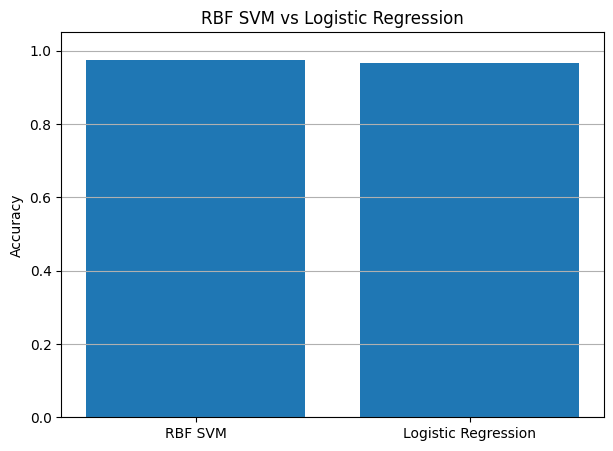

In [11]:
models = ["RBF SVM", "Logistic Regression"]

accuracies = [
    accuracy_list[2],
    log_accuracy
]

plt.figure(figsize=(7, 5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("RBF SVM vs Logistic Regression")
plt.ylim(0, 1.05)

plt.grid(axis="y")

plt.show()